<a href="https://colab.research.google.com/github/Evenjlin/deep-space-interference-ml/blob/main/notebooks/09_decision_aware_mitigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Cell 1 — self-contained bootstrap
from google.colab import userdata
import torch, os, sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_EMAIL = "evenjlinekka@gmail.com"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/Evenjlin/deep-space-interference-ml.git"

if not os.path.exists('/content/deep-space-interference-ml'):
    !git clone {REPO_URL} /content/deep-space-interference-ml
%cd /content/deep-space-interference-ml
!git config --global user.email "{GITHUB_EMAIL}"
!git config --global user.name "Evenjlin"
!git remote set-url origin {REPO_URL}
!git pull

!pip install -r requirements.txt -q
sys.path.insert(0, os.getcwd())

Device: cuda
/content/deep-space-interference-ml
Already up to date.


In [2]:
# Cell 2 — data pipeline WITH metadata (bits, fd, phi_m, k_shift) for the decision-aware loss
import numpy as np
import torch
from src.channel import SignalConfig, mix_signal
from src.model import MitigationAutoencoder, complex_to_channels
from src.evaluate import matched_filter_ber, theoretical_ber
from src.train import decision_aware_loss, train_mitigation_ae_decision_aware

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = SignalConfig(fd_max=0.0)
rng = np.random.default_rng(42)

N_SYMBOLS = 1024  # BASE-PAPER FACT, same as Step 8b/c for direct comparability
SNR_RANGE_TRAIN = (-15, 30)
SIR_RANGE_TRAIN = (-10, 30)
INTERFERENCE_TYPE = "tone"  # start here -- already have Step 8b's MSE-only baseline to compare against

def make_mitigation_pair_with_meta(cfg, n_symbols, snr_range, sir_range, interference_type, rng):
    d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type,
                    contamination=0.5, sir_db_range=sir_range, snr_db_range=snr_range, apply_shift=False)
    X = complex_to_channels(d["x"]).astype(np.float32)
    Y = complex_to_channels(d["s"]).astype(np.float32)
    return X, Y, d["bits"], d["fd"], d["phi_m"], d["k_shift"]

def build_dataset_with_meta(n):
    X, Y, bits, fd, phi_m, k_shift = [], [], [], [], [], []
    for _ in range(n):
        x, y, b, f, p, k = make_mitigation_pair_with_meta(cfg, N_SYMBOLS, SNR_RANGE_TRAIN, SIR_RANGE_TRAIN, INTERFERENCE_TYPE, rng)
        X.append(x); Y.append(y); bits.append(b); fd.append(f); phi_m.append(p); k_shift.append(k)
    return (np.stack(X), np.stack(Y), np.stack(bits).astype(np.int64),
            np.array(fd, dtype=np.float32), np.array(phi_m, dtype=np.float32), np.array(k_shift, dtype=np.int64))

M_TRAIN, M_VAL = 1500, 400
X_train, Y_train, bits_train, fd_train, phi_train, k_train = build_dataset_with_meta(M_TRAIN)
X_val, Y_val, bits_val, fd_val, phi_val, k_val = build_dataset_with_meta(M_VAL)
print("X_train:", X_train.shape, " bits_train:", bits_train.shape, " fd range:", fd_train.min(), fd_train.max())

X_train: (1500, 2, 8192)  bits_train: (1500, 1024)  fd range: 0.0 0.0


In [3]:
# Cell 3 — DEBUG LADDER for the new loss function (critical: this is genuinely new, untested code)
model = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)

tiny_x = torch.tensor(X_train[:8], device=device)
tiny_y = torch.tensor(Y_train[:8], device=device)
tiny_bits = torch.tensor(bits_train[:8], device=device, dtype=torch.long)
tiny_fd = torch.tensor(fd_train[:8], device=device, dtype=torch.float32)
tiny_phi = torch.tensor(phi_train[:8], device=device, dtype=torch.float32)
tiny_k = torch.tensor(k_train[:8], device=device, dtype=torch.long)

out = model(tiny_x)
print("TEST 1: output shape", out.shape)
assert out.shape == tiny_x.shape

loss, mse_val, dec_val = decision_aware_loss(out, tiny_y, tiny_bits, tiny_fd, tiny_phi, tiny_k, cfg, N_SYMBOLS)
print(f"TEST 2: loss computed OK -- total={loss.item():.4f}  mse={mse_val:.4f}  decision={dec_val:.4f}")

opt = torch.optim.Adam(model.parameters(), lr=3e-5)
loss.backward()
print("TEST 3: backward() succeeded -- gradients flow through the de-rotation math")
opt.step(); opt.zero_grad()

# TEST 4: a few steps, confirm total loss decreases
small_x = torch.tensor(X_train[:200], device=device)
small_y = torch.tensor(Y_train[:200], device=device)
small_bits = torch.tensor(bits_train[:200], device=device, dtype=torch.long)
small_fd = torch.tensor(fd_train[:200], device=device, dtype=torch.float32)
small_phi = torch.tensor(phi_train[:200], device=device, dtype=torch.float32)
small_k = torch.tensor(k_train[:200], device=device, dtype=torch.long)

losses = []
for _ in range(20):
    opt.zero_grad()
    out = model(small_x)
    loss, mse_val, dec_val = decision_aware_loss(out, small_y, small_bits, small_fd, small_phi, small_k, cfg, N_SYMBOLS)
    loss.backward(); opt.step()
    losses.append((loss.item(), mse_val, dec_val))

print("TEST 4 losses (total, mse, decision):")
for t, m, d in losses:
    print(f"  total={t:.4f}  mse={m:.4f}  decision={d:.4f}")
assert losses[-1][0] < losses[0][0], "Total loss did not decrease -- STOP, don't proceed"
print("Debug ladder PASSED.")

TEST 1: output shape torch.Size([8, 2, 8192])
TEST 2: loss computed OK -- total=2.1981  mse=2.1309  decision=0.0672
TEST 3: backward() succeeded -- gradients flow through the de-rotation math
TEST 4 losses (total, mse, decision):
  total=1.5806  mse=1.5170  decision=0.0637
  total=1.5764  mse=1.5129  decision=0.0635
  total=1.5728  mse=1.5094  decision=0.0634
  total=1.5698  mse=1.5065  decision=0.0633
  total=1.5673  mse=1.5041  decision=0.0632
  total=1.5652  mse=1.5021  decision=0.0631
  total=1.5633  mse=1.5003  decision=0.0630
  total=1.5616  mse=1.4986  decision=0.0630
  total=1.5601  mse=1.4971  decision=0.0630
  total=1.5587  mse=1.4957  decision=0.0629
  total=1.5573  mse=1.4944  decision=0.0629
  total=1.5560  mse=1.4932  decision=0.0629
  total=1.5548  mse=1.4920  decision=0.0629
  total=1.5537  mse=1.4908  decision=0.0629
  total=1.5526  mse=1.4898  decision=0.0628
  total=1.5516  mse=1.4888  decision=0.0628
  total=1.5506  mse=1.4878  decision=0.0628
  total=1.5497  mse=1.

Epoch 1/100  total=3.3563  mse=1.7310  decision=0.0650  val_total=3.6200
Epoch 5/100  total=3.1729  mse=1.6369  decision=0.0614  val_total=3.4557
Epoch 10/100  total=2.7941  mse=1.4935  decision=0.0520  val_total=3.1136
Epoch 15/100  total=2.4568  mse=1.3808  decision=0.0430  val_total=2.8450
Epoch 20/100  total=2.2880  mse=1.3025  decision=0.0394  val_total=2.7038
Epoch 25/100  total=2.1943  mse=1.2526  decision=0.0377  val_total=2.6322
Epoch 30/100  total=2.1344  mse=1.2184  decision=0.0366  val_total=2.5790
Epoch 35/100  total=2.0836  mse=1.1886  decision=0.0358  val_total=2.5253
Epoch 40/100  total=2.0455  mse=1.1669  decision=0.0351  val_total=2.4838
Epoch 45/100  total=2.0105  mse=1.1451  decision=0.0346  val_total=2.4569
Epoch 50/100  total=1.9884  mse=1.1309  decision=0.0343  val_total=2.4254
Epoch 55/100  total=1.9599  mse=1.1114  decision=0.0339  val_total=2.4048
Epoch 60/100  total=1.9315  mse=1.0916  decision=0.0336  val_total=2.3725
Epoch 65/100  total=1.9043  mse=1.0713  

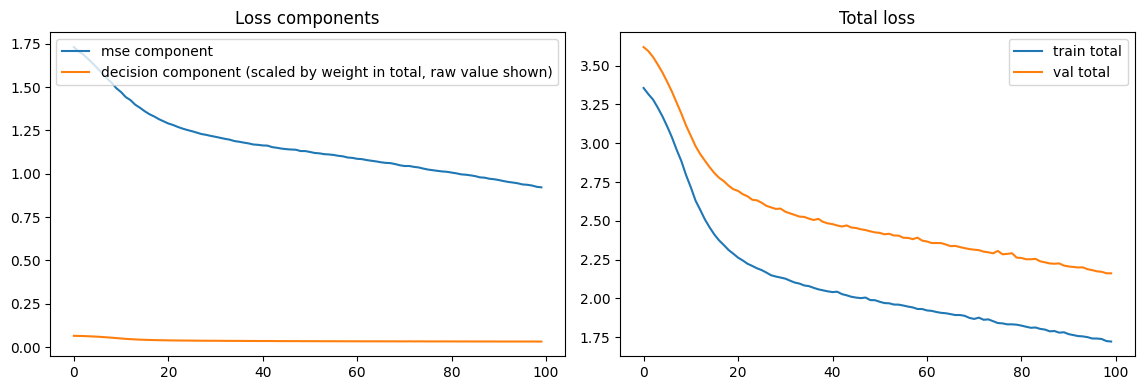

Final: mse=0.9217  decision=0.0320


In [4]:
# Cell 4 — full training with rescaled decision_weight (OUR ASSUMPTION: ~25x default,
# chosen from the observed mse/decision magnitude ratio in the debug ladder — not yet tuned)
model_decision_aware = MitigationAutoencoder(n_stages=2, n_hidden=32)
model_decision_aware, history_da = train_mitigation_ae_decision_aware(
    model_decision_aware, X_train, Y_train, bits_train, fd_train, phi_train, k_train,
    X_val, Y_val, bits_val, fd_val, phi_val, k_val,
    cfg, N_SYMBOLS, device,
    epochs=100, batch_size=32, lr=3e-5, patience=15,
    decision_weight=25.0, margin=0.3
)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history_da["train_mse"], label="mse component")
axes[0].plot(history_da["train_decision"], label="decision component (scaled by weight in total, raw value shown)")
axes[0].set_title("Loss components"); axes[0].legend()
axes[1].plot(history_da["train_total"], label="train total")
axes[1].plot(history_da["val_total"], label="val total")
axes[1].set_title("Total loss"); axes[1].legend()
plt.tight_layout()
plt.savefig("figures/step9_decision_aware_training.png", dpi=150)
plt.show()

torch.save(model_decision_aware.state_dict(), "checkpoints/mitigation_ae_tone_decision_aware.pt")
print(f"Final: mse={history_da['train_mse'][-1]:.4f}  decision={history_da['train_decision'][-1]:.4f}")

Eb/N0=0dB  interference=0.3232  MSE-only=0.4422  decision-aware=0.2246  clean=0.1577
Eb/N0=1dB  interference=0.3162  MSE-only=0.4664  decision-aware=0.1988  clean=0.1327
Eb/N0=2dB  interference=0.3174  MSE-only=0.4829  decision-aware=0.1756  clean=0.1036
Eb/N0=3dB  interference=0.3368  MSE-only=0.4983  decision-aware=0.1545  clean=0.0791
Eb/N0=4dB  interference=0.3377  MSE-only=0.5022  decision-aware=0.1307  clean=0.0574
Eb/N0=5dB  interference=0.3193  MSE-only=0.5002  decision-aware=0.1068  clean=0.0378
Eb/N0=6dB  interference=0.3041  MSE-only=0.5028  decision-aware=0.0922  clean=0.0226


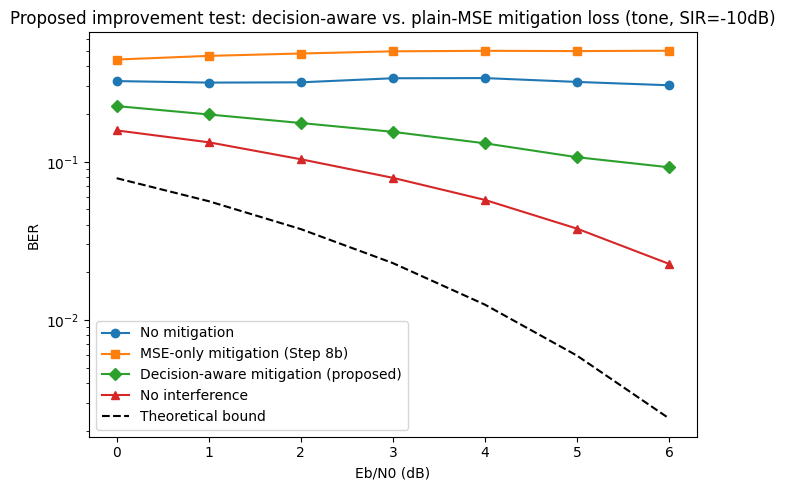

In [5]:
# Cell 5 — head-to-head BER comparison: decision-aware vs plain-MSE baseline (Step 8b)
from src.channel import mix_signal
from src.evaluate import matched_filter_ber, theoretical_ber

def ae_denoise(x_complex, model, device):
    channels = complex_to_channels(x_complex).astype(np.float32)
    with torch.no_grad():
        inp = torch.tensor(channels, device=device).unsqueeze(0)
        out = model(inp).squeeze(0).cpu().numpy()
    return out[0] + 1j*out[1]

# Load Step 8b's plain-MSE baseline for direct comparison
model_mse_baseline = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
model_mse_baseline.load_state_dict(torch.load("checkpoints/mitigation_ae_tone.pt", map_location=device))
model_mse_baseline.eval()
model_decision_aware.eval()

SIR_DB_TEST = -10.0  # BASE-PAPER FACT, same as Step 8b for direct comparability
EBN0_RANGE = [0, 1, 2, 3, 4, 5, 6]
N_TRIALS = 100

comparison_results = []
for ebn0_db in EBN0_RANGE:
    snr_db = ebn0_db - 10*np.log10(cfg.NSPS)
    ber_int, ber_mse_only, ber_decision_aware, ber_clean = [], [], [], []

    for _ in range(N_TRIALS):
        d = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=1.0,
                        sir_db_range=(SIR_DB_TEST, SIR_DB_TEST), snr_db_range=(snr_db, snr_db), apply_shift=False)
        x, bits, fd, phi_m, k_shift = d["x"], d["bits"], d["fd"], d["phi_m"], d["k_shift"]

        ber_int.append(matched_filter_ber(x, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        x_mse = ae_denoise(x, model_mse_baseline, device)
        ber_mse_only.append(matched_filter_ber(x_mse, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        x_da = ae_denoise(x, model_decision_aware, device)
        ber_decision_aware.append(matched_filter_ber(x_da, bits, cfg, N_SYMBOLS, fd, phi_m, k_shift))

        d_clean = mix_signal(cfg, N_SYMBOLS, rng, interference_type="tone", contamination=0.0,
                              snr_db_range=(snr_db, snr_db), apply_shift=False)
        ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, N_SYMBOLS,
                                              d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))

    comparison_results.append({
        "ebn0_db": ebn0_db,
        "ber_with_interference": np.mean(ber_int),
        "ber_mse_only": np.mean(ber_mse_only),
        "ber_decision_aware": np.mean(ber_decision_aware),
        "ber_no_interference": np.mean(ber_clean),
        "ber_theoretical": theoretical_ber(ebn0_db),
    })
    print(f"Eb/N0={ebn0_db}dB  interference={np.mean(ber_int):.4f}  "
          f"MSE-only={np.mean(ber_mse_only):.4f}  decision-aware={np.mean(ber_decision_aware):.4f}  "
          f"clean={np.mean(ber_clean):.4f}")

import pandas as pd
comp_df = pd.DataFrame(comparison_results)
comp_df.to_csv("results/step9_decision_aware_vs_mse_comparison.csv", index=False)

plt.figure(figsize=(7,5))
plt.semilogy(comp_df["ebn0_db"], comp_df["ber_with_interference"], marker='o', label="No mitigation")
plt.semilogy(comp_df["ebn0_db"], comp_df["ber_mse_only"], marker='s', label="MSE-only mitigation (Step 8b)")
plt.semilogy(comp_df["ebn0_db"], comp_df["ber_decision_aware"], marker='D', label="Decision-aware mitigation (proposed)")
plt.semilogy(comp_df["ebn0_db"], comp_df["ber_no_interference"], marker='^', label="No interference")
plt.semilogy(comp_df["ebn0_db"], comp_df["ber_theoretical"], linestyle='--', color='black', label="Theoretical bound")
plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
plt.title("Proposed improvement test: decision-aware vs. plain-MSE mitigation loss (tone, SIR=-10dB)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/step9_decision_aware_vs_mse.png", dpi=150)
plt.show()


==================== SQUARE (decision-aware) ====================
X_train: (1500, 2, 8192)
Sanity check -- total=1.2307  mse=0.7822  decision=0.0179
Epoch 1/100  total=3.1628  mse=1.8218  decision=0.0536  val_total=3.3910
Epoch 5/100  total=2.9944  mse=1.6742  decision=0.0528  val_total=3.2061
Epoch 10/100  total=2.6754  mse=1.4292  decision=0.0498  val_total=2.8887
Epoch 15/100  total=2.3835  mse=1.2333  decision=0.0460  val_total=2.6173
Epoch 20/100  total=2.2004  mse=1.0996  decision=0.0440  val_total=2.4460
Epoch 25/100  total=2.0806  mse=1.0069  decision=0.0429  val_total=2.3214
Epoch 30/100  total=1.9966  mse=0.9381  decision=0.0423  val_total=2.2458
Epoch 35/100  total=1.9507  mse=0.8912  decision=0.0424  val_total=2.2016
Epoch 40/100  total=1.8908  mse=0.8464  decision=0.0418  val_total=2.1206
Epoch 45/100  total=1.8280  mse=0.8042  decision=0.0409  val_total=2.0731
Epoch 50/100  total=1.7960  mse=0.7757  decision=0.0408  val_total=2.0269
Epoch 55/100  total=1.7618  mse=0.7485

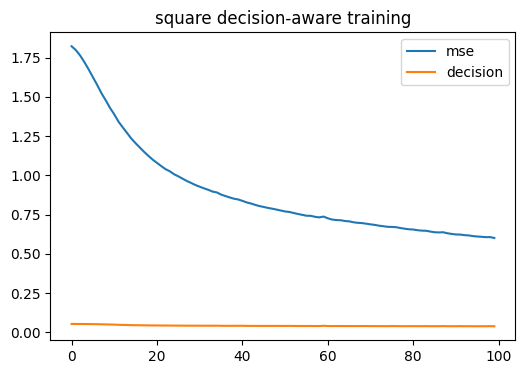

Eb/N0=0dB  no_mit=0.2813  MSE=0.4210  decision-aware=0.2793  clean=0.1575
Eb/N0=1dB  no_mit=0.2823  MSE=0.4426  decision-aware=0.2707  clean=0.1309
Eb/N0=2dB  no_mit=0.2545  MSE=0.4564  decision-aware=0.2424  clean=0.1039
Eb/N0=3dB  no_mit=0.2559  MSE=0.4677  decision-aware=0.2426  clean=0.0789
Eb/N0=4dB  no_mit=0.2444  MSE=0.4719  decision-aware=0.2253  clean=0.0566
Eb/N0=5dB  no_mit=0.2534  MSE=0.4734  decision-aware=0.2172  clean=0.0375
Eb/N0=6dB  no_mit=0.2577  MSE=0.4731  decision-aware=0.2175  clean=0.0234


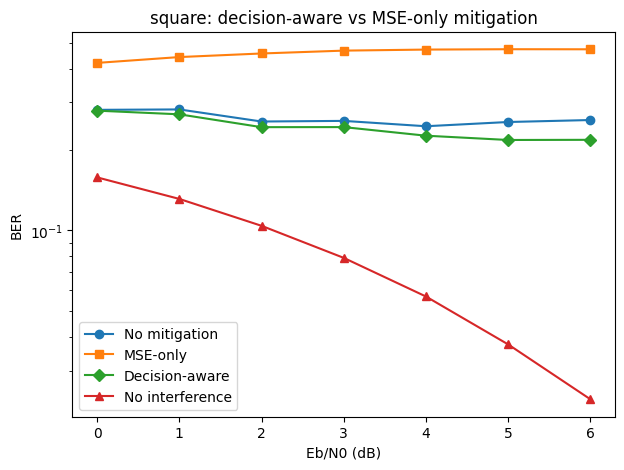

In [7]:
# Cell 6 — reusable decision-aware training + head-to-head BER comparison
def run_decision_aware_experiment(interference_type, cfg, rng, device, n_symbols=1024,
                                    snr_range=(-15, 30), sir_range=(-10, 30),
                                    m_train=1500, m_val=400, sir_db_test=-10.0,
                                    ebn0_range=(0,1,2,3,4,5,6), n_trials=100,
                                    decision_weight=25.0, margin=0.3):
    print(f"\n{'='*20} {interference_type.upper()} (decision-aware) {'='*20}")

    # Data with metadata
    def build(n):
        X, Y, bits, fd, phi_m, k_shift = [], [], [], [], [], []
        for _ in range(n):
            d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type,
                            contamination=0.5, sir_db_range=sir_range, snr_db_range=snr_range, apply_shift=False)
            X.append(complex_to_channels(d["x"]).astype(np.float32))
            Y.append(complex_to_channels(d["s"]).astype(np.float32))
            bits.append(d["bits"]); fd.append(d["fd"]); phi_m.append(d["phi_m"]); k_shift.append(d["k_shift"])
        return (np.stack(X), np.stack(Y), np.stack(bits).astype(np.int64),
                np.array(fd, dtype=np.float32), np.array(phi_m, dtype=np.float32), np.array(k_shift, dtype=np.int64))

    X_train, Y_train, bits_train, fd_train, phi_train, k_train = build(m_train)
    X_val, Y_val, bits_val, fd_val, phi_val, k_val = build(m_val)
    print(f"X_train: {X_train.shape}")

    # Debug check (lighter than full ladder -- recipe already validated for tone)
    model = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
    tiny_out = model(torch.tensor(X_train[:8], device=device))
    tiny_loss, tiny_mse, tiny_dec = decision_aware_loss(
        tiny_out, torch.tensor(Y_train[:8], device=device),
        torch.tensor(bits_train[:8], device=device, dtype=torch.long),
        torch.tensor(fd_train[:8], device=device, dtype=torch.float32),
        torch.tensor(phi_train[:8], device=device, dtype=torch.float32),
        torch.tensor(k_train[:8], device=device, dtype=torch.long),
        cfg, n_symbols, decision_weight=decision_weight, margin=margin)
    print(f"Sanity check -- total={tiny_loss.item():.4f}  mse={tiny_mse:.4f}  decision={tiny_dec:.4f}")

    # Training
    model = MitigationAutoencoder(n_stages=2, n_hidden=32)
    model, history = train_mitigation_ae_decision_aware(
        model, X_train, Y_train, bits_train, fd_train, phi_train, k_train,
        X_val, Y_val, bits_val, fd_val, phi_val, k_val,
        cfg, n_symbols, device, epochs=100, batch_size=32, lr=3e-5, patience=15,
        decision_weight=decision_weight, margin=margin)

    plt.figure(figsize=(6,4))
    plt.plot(history["train_mse"], label="mse"); plt.plot(history["train_decision"], label="decision")
    plt.title(f"{interference_type} decision-aware training"); plt.legend()
    plt.savefig(f"figures/step9_{interference_type}_decision_aware_training.png", dpi=150)
    plt.show()
    torch.save(model.state_dict(), f"checkpoints/mitigation_ae_{interference_type}_decision_aware.pt")

    # Load matching Step 8c MSE-only baseline for this type
    model_mse = MitigationAutoencoder(n_stages=2, n_hidden=32).to(device)
    model_mse.load_state_dict(torch.load(f"checkpoints/mitigation_ae_{interference_type}.pt", map_location=device))
    model_mse.eval(); model.eval()

    # Head-to-head BER
    rows = []
    for ebn0_db in ebn0_range:
        snr_db = ebn0_db - 10*np.log10(cfg.NSPS)
        ber_int, ber_mse, ber_da, ber_clean = [], [], [], []
        for _ in range(n_trials):
            d = mix_signal(cfg, n_symbols, rng, interference_type=interference_type, contamination=1.0,
                            sir_db_range=(sir_db_test, sir_db_test), snr_db_range=(snr_db, snr_db), apply_shift=False)
            ber_int.append(matched_filter_ber(d["x"], d["bits"], cfg, n_symbols, d["fd"], d["phi_m"], d["k_shift"]))
            ber_mse.append(matched_filter_ber(ae_denoise(d["x"], model_mse, device), d["bits"], cfg, n_symbols, d["fd"], d["phi_m"], d["k_shift"]))
            ber_da.append(matched_filter_ber(ae_denoise(d["x"], model, device), d["bits"], cfg, n_symbols, d["fd"], d["phi_m"], d["k_shift"]))
            d_clean = mix_signal(cfg, n_symbols, rng, interference_type=interference_type, contamination=0.0,
                                  snr_db_range=(snr_db, snr_db), apply_shift=False)
            ber_clean.append(matched_filter_ber(d_clean["x"], d_clean["bits"], cfg, n_symbols, d_clean["fd"], d_clean["phi_m"], d_clean["k_shift"]))
        rows.append({"ebn0_db": ebn0_db, "ber_no_mitigation": np.mean(ber_int), "ber_mse_only": np.mean(ber_mse),
                     "ber_decision_aware": np.mean(ber_da), "ber_no_interference": np.mean(ber_clean)})
        print(f"Eb/N0={ebn0_db}dB  no_mit={np.mean(ber_int):.4f}  MSE={np.mean(ber_mse):.4f}  decision-aware={np.mean(ber_da):.4f}  clean={np.mean(ber_clean):.4f}")

    df = pd.DataFrame(rows)
    df.to_csv(f"results/step9_{interference_type}_decision_aware_comparison.csv", index=False)

    plt.figure(figsize=(7,5))
    plt.semilogy(df["ebn0_db"], df["ber_no_mitigation"], marker='o', label="No mitigation")
    plt.semilogy(df["ebn0_db"], df["ber_mse_only"], marker='s', label="MSE-only")
    plt.semilogy(df["ebn0_db"], df["ber_decision_aware"], marker='D', label="Decision-aware")
    plt.semilogy(df["ebn0_db"], df["ber_no_interference"], marker='^', label="No interference")
    plt.title(f"{interference_type}: decision-aware vs MSE-only mitigation"); plt.legend()
    plt.xlabel("Eb/N0 (dB)"); plt.ylabel("BER")
    plt.savefig(f"figures/step9_{interference_type}_decision_aware_comparison.png", dpi=150)
    plt.show()

    return model, history, df

# Run SQUARE first
model_da_square, history_da_square, df_da_square = run_decision_aware_experiment("square", cfg, rng, device)


==================== CHIRP (decision-aware) ====================
X_train: (1500, 2, 8192)
Sanity check -- total=6.6230  mse=3.6624  decision=0.1184
Epoch 1/100  total=3.6699  mse=1.8432  decision=0.0731  val_total=3.1444
Epoch 5/100  total=3.3696  mse=1.7048  decision=0.0666  val_total=2.8906
Epoch 10/100  total=2.8102  mse=1.5248  decision=0.0514  val_total=2.4367
Epoch 15/100  total=2.5331  mse=1.4322  decision=0.0440  val_total=2.2463
Epoch 20/100  total=2.4095  mse=1.3761  decision=0.0413  val_total=2.1629
Epoch 25/100  total=2.3340  mse=1.3329  decision=0.0400  val_total=2.1024
Epoch 30/100  total=2.2634  mse=1.2920  decision=0.0389  val_total=2.0540
Epoch 35/100  total=2.2168  mse=1.2602  decision=0.0383  val_total=2.0178
Epoch 40/100  total=2.1605  mse=1.2234  decision=0.0375  val_total=1.9772
Epoch 45/100  total=2.1167  mse=1.1884  decision=0.0371  val_total=1.9537
Epoch 50/100  total=2.0758  mse=1.1543  decision=0.0369  val_total=1.9144
Epoch 55/100  total=2.0281  mse=1.1185 

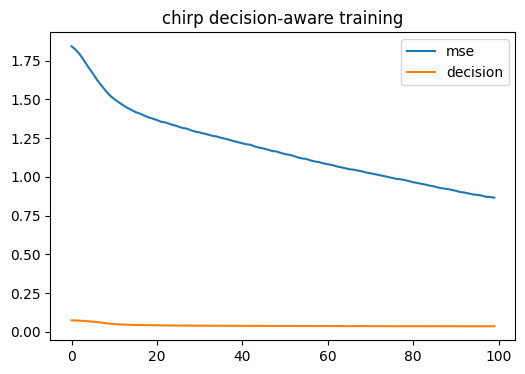

Eb/N0=0dB  no_mit=0.3703  MSE=0.4167  decision-aware=0.2194  clean=0.1583
Eb/N0=1dB  no_mit=0.3537  MSE=0.4233  decision-aware=0.1907  clean=0.1309
Eb/N0=2dB  no_mit=0.3706  MSE=0.4387  decision-aware=0.1636  clean=0.1047
Eb/N0=3dB  no_mit=0.3642  MSE=0.4445  decision-aware=0.1364  clean=0.0776
Eb/N0=4dB  no_mit=0.3594  MSE=0.4485  decision-aware=0.1096  clean=0.0557
Eb/N0=5dB  no_mit=0.3695  MSE=0.4438  decision-aware=0.0882  clean=0.0373
Eb/N0=6dB  no_mit=0.3704  MSE=0.4458  decision-aware=0.0707  clean=0.0221


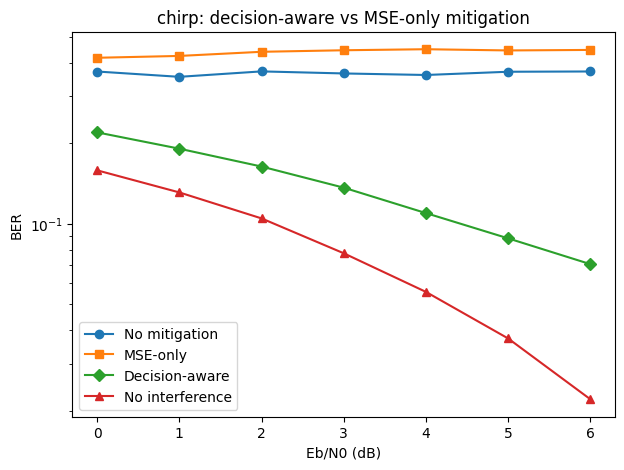

In [8]:
# Run CHIRP
model_da_chirp, history_da_chirp, df_da_chirp = run_decision_aware_experiment("chirp", cfg, rng, device)